Optimal value (Z): 21.0
Optimal values (x, y): [3.  1.5]


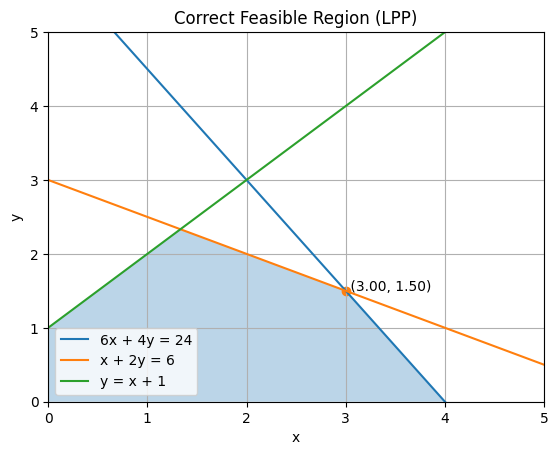

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# Objective function (Maximize Z = 5x + 4y → minimize -Z)
c = [-5, -4]

# Constraints
A = [
    [6, 4],
    [1, 2],
    [-1, 1]
]

b = [24, 6, 1]

# Bounds
bounds = [(0, None), (0, None)]

# Solve
result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

print("Optimal value (Z):", -result.fun)
print("Optimal values (x, y):", result.x)

# -------------------------------
# Plotting
x = np.linspace(0, 5, 400)

y1 = (24 - 6*x) / 4      # 6x + 4y = 24
y2 = (6 - x) / 2         # x + 2y = 6
y3 = x + 1               # y = x + 1

plt.plot(x, y1, label="6x + 4y = 24")
plt.plot(x, y2, label="x + 2y = 6")
plt.plot(x, y3, label="y = x + 1")

# ✅ Correct feasible region
feasible_x = [0, 0, 4/3, 3, 4]
feasible_y = [0, 1, 7/3, 1.5, 0]

plt.fill(feasible_x, feasible_y, alpha=0.3)

# Optimal point
opt_x, opt_y = result.x
plt.scatter(opt_x, opt_y)
plt.text(opt_x, opt_y, f" ({opt_x:.2f}, {opt_y:.2f})")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Correct Feasible Region (LPP)")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.legend()
plt.grid()

plt.show()